# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import matplotlib.ticker as ticker # Custom formatter: Format y-axis labels as Millions/Thousands
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score,
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold,
    validation_curve
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# ============================================
# Custom Formatter Functions
# ============================================

# Format numbers in thousands (e.g., 10,000 → 10K)
def thousands_formatter(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.0f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

# Format dollars in millions/thousands
def dollars_formatter(x, pos):
    if x >= 1e6:
        return f'${x/1e6:.1f}M'
    elif x >= 1e3:
        return f'${x/1e3:.0f}K'
    else:
        return f'${x:.0f}'

# Register the formatters
thousands_fmt = ticker.FuncFormatter(thousands_formatter)
dollars_fmt = ticker.FuncFormatter(dollars_formatter)


## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [4]:
# ==============================================================================
# MILESTONE 2: Load Preprocessed Dataset from Milestone 1 Project. New datasets
# ==============================================================================
base_url = "https://github.com/dn603/Module-3-Milestone-2/raw/refs/heads/main/"

# List of files to download (FREQUENCY ENCODING VERSION)
files = [
    "X_train_freq.csv.zip",
    "X_test_freq.csv.zip",
    "y_train_freq.csv.zip",
    "y_test_freq.csv.zip"
]

downloaded_data = {}

for file in files:
    url = base_url + file
    filename = os.path.basename(urlparse(url).path)
    
    if not os.path.exists(filename):
        try:
            print(f"Downloading {file}...")
            response = requests.get(url)
            response.raise_for_status()
            with open(filename, "wb") as f:
                f.write(response.content)
            print(f"   {file} downloaded successfully.")
        except requests.exceptions.RequestException as e:
            print(f"   Error downloading {file}: {e}")
    else:
        print(f"   {file} already exists. Skipping download.")

# Load the files
X_train = pd.read_csv("X_train_freq.csv.zip")
X_test = pd.read_csv("X_test_freq.csv.zip")
y_train = pd.read_csv("y_train_freq.csv.zip").squeeze("columns")
y_test = pd.read_csv("y_test_freq.csv.zip").squeeze("columns")

   X_train_freq.csv.zip already exists. Skipping download.
   X_test_freq.csv.zip already exists. Skipping download.
   y_train_freq.csv.zip already exists. Skipping download.
   y_test_freq.csv.zip already exists. Skipping download.


In [9]:
# ============================================
# MILESTONE 2: DATASET SUMMARY (Frequency Encoding)
# ============================================

print("=" * 60)
print("MILESTONE 2: DATASET SUMMARY")
print("=" * 60)

print(f"\nTraining Set:")
print(f"   X_train: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
print(f"   y_train: {y_train.shape[0]:,} samples")

print(f"\nTest Set:")
print(f"   X_test: {X_test.shape[0]:,} samples, {X_test.shape[1]:,} features")
print(f"   y_test: {y_test.shape[0]:,} samples")

# Combine train and test to show full dataset stats
total_rows = X_train.shape[0] + X_test.shape[0]
total_features = X_train.shape[1]  # Should be same as X_test

print(f"\nFull Dataset (Combined):")
print(f"   Total rows:    {total_rows:,}")
print(f"   Total columns: {total_features:,}")

# Check for missing values
print(f"\nData Quality:")
print(f"   Missing values in X_train: {X_train.isnull().sum().sum():,}")
print(f"   Missing values in X_test:  {X_test.isnull().sum().sum():,}")

# Target variable statistics (using y_train + y_test)
y_full = pd.concat([y_train, y_test])
print(f"\nTarget (taxvaluedollarcnt):")
print(f"   Mean:  ${y_full.mean():,.2f}")
print(f"   Median: ${y_full.median():,.2f}")
print(f"   Min:   ${y_full.min():,.2f}")
print(f"   Max:   ${y_full.max():,.2f}")

# Column types
print(f"\nColumn Types:")
print(f"   Numeric columns: {X_train.select_dtypes(include=['number']).shape[1]:,}")
print(f"   Object columns:  {X_train.select_dtypes(include=['object']).shape[1]:,}")

print("\nFREQUENCY-ENCODED DATASETS ARE CLEAN AND READY!")

MILESTONE 2: DATASET SUMMARY

Training Set:
   X_train: 62,057 samples, 28 features
   y_train: 62,057 samples

Test Set:
   X_test: 15,515 samples, 28 features
   y_test: 15,515 samples

Full Dataset (Combined):
   Total rows:    77,572
   Total columns: 28

Data Quality:
   Missing values in X_train: 0
   Missing values in X_test:  0

Target (taxvaluedollarcnt):
   Mean:  $490,072.32
   Median: $358,878.50
   Min:   $1,000.00
   Max:   $49,061,236.00

Column Types:
   Numeric columns: 28
   Object columns:  0

FREQUENCY-ENCODED DATASETS ARE CLEAN AND READY!


## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [10]:
# ============================================
# PART 1: Model Selection and Baselines
# ============================================

# We agreed on using the following models for our baseline comparisons:
# Linear Regression, Random Forest, and Decision Tree.

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

# Repeated CV setup and check for overfitting
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

results = []

for name, model in models.items():
    print(f"\n{name}:")
    print("~" * 30)

    # Fit on full training set
    model.fit(X_train, y_train)
    
    # Predict on training set
    y_train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation scores (negative MAE)
    neg_mae_scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=repeated_cv,
        n_jobs=-1
    )
    
    # Convert to positive MAE
    mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(mae_scores)
    std_cv_mae = np.std(mae_scores)

    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")
    
    # Store results
    results.append({
        'Model Name': name,
        'Train MAE': train_mae,
        'Mean CV MAE': mean_cv_mae,
        'Std CV MAE': std_cv_mae,
    })

# Find best model
results_df = pd.DataFrame(results)
best_idx = np.argmin(results_df['Mean CV MAE'])
print("\n" + "=" * 30)
print(f"BEST MODEL: {results_df.iloc[best_idx]['Model Name']}")
print(f"   Mean CV MAE: ${results_df.iloc[best_idx]['Mean CV MAE']:,.2f}")
print(f"   Std CV MAE:  ${results_df.iloc[best_idx]['Std CV MAE']:,.2f}")


Linear Regression:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $245,626.68
   Mean CV MAE:  $245,910.67
   Std CV MAE:   $3,260.89

Random Forest:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $71,685.22
   Mean CV MAE:  $191,951.14
   Std CV MAE:   $3,146.39

Decision Tree:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,598.07
   Mean CV MAE:  $254,293.24
   Std CV MAE:   $3,111.16

BEST MODEL: Random Forest
   Mean CV MAE: $191,951.14
   Std CV MAE:  $3,146.39


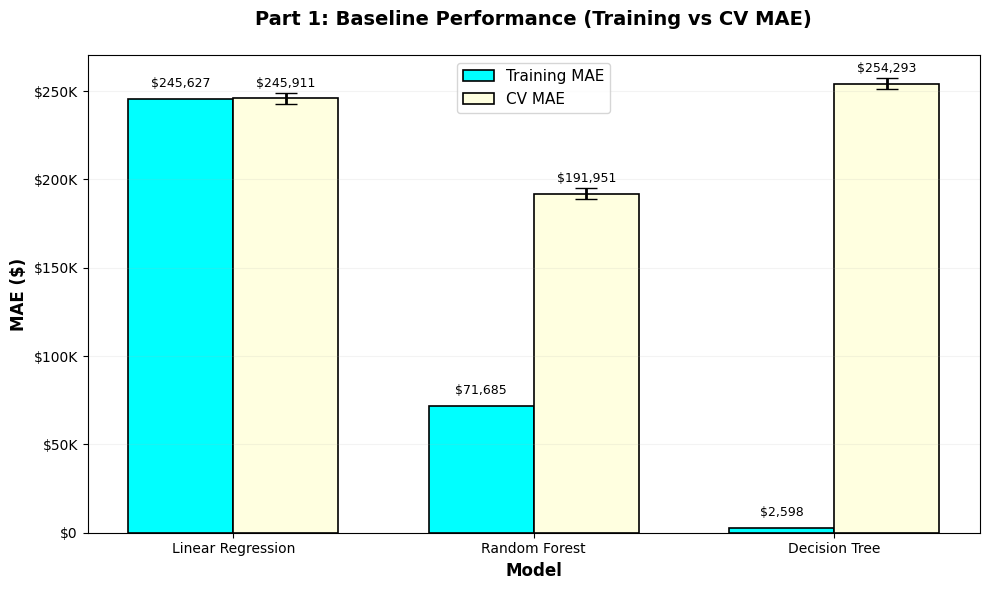

In [53]:
# ============================================
# PART 1: BASELINE PERFORMANCE VISUALIZATION
# ============================================

# Data
models = ['Linear Regression', 'Random Forest', 'Decision Tree']
train_mae = [245626.68, 71685.22, 2598.07]
cv_mae = [245910.67, 191951.14, 254293.24]
cv_std = [3260.89, 3146.39, 3111.16]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Bars
bars1 = ax.bar(x - width/2, train_mae, width, label='Training MAE', 
               color='aqua', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, cv_mae, width, yerr=cv_std, label='CV MAE', 
               color='lightyellow', edgecolor='black', linewidth=1.2,
               capsize=8, error_kw={'linewidth': 2})

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5000,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 5000,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE ($)', fontsize=12, fontweight='bold')
ax.set_title('Part 1: Baseline Performance (Training vs CV MAE)\n', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.15, axis='y')
ax.yaxis.set_major_formatter(dollars_fmt)

plt.tight_layout()
plt.show()

### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score **?

- The **Random Forest** model has the **lowest** validation MAE with **$191,951.14**

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

- The **Linear Regression** model has the **smallest** standard deviation **$3,111.16**
- **Linear Regression** is the most stable across different data splits
- **Random Forest** is nearly as stable with better predictive performance **(\$3,146.39)** 
- **Decision Tree** shows the most variability and less reliable generalization **($3,260.89)**

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

- The **Decistion Tree** Training MAE has: 2,598 - 254,293 = **-\$251,695** gap, which indicates **overfitting** 
    - The **Training MAE** is very **low**, which means it almost memorizes the data
    - The **CV MAE** has the **highest** value out of the three models. This indicates it fails to generalize
- The **Linear Regression** model appears to be underfit. 
    - This model has the **highest Training MAE** score of **\$245,626.68** out of the 3 models
    - The gap between the **Training MAE** and **The CV MAE** is only **\$283.99**

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

- **Linear Regression**: Simple, stable, but has low accuracy
- **Random Forest**: Best accuracy, stable performance (low  **Std CV MAE: $3,146**), but overfit the training data
- **Decision Tree**: The most overfitting model (Training MAE is very low, while CV MAE is the highest)

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats). 
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [11]:
# ================================================
# PART 2: Evaluate Feature Engineering Hypotheses
# ================================================

# BASELINE RESULTS (from Part 1)
baseline_results = {
    'Linear Regression': {
        'Mean CV MAE': 245910.67,
        'Std CV MAE': 3260.89,
        'Train MAE': 245626.68
    },
    'Random Forest': {
        'Mean CV MAE': 191951.14,
        'Std CV MAE': 3146.39,
        'Train MAE': 71685.22
    },
    'Decision Tree': {
        'Mean CV MAE': 254293.24,
        'Std CV MAE': 3111.16,
        'Train MAE': 2598.07
    }
}
baseline_df = pd.DataFrame(baseline_results).T

# From your Milestone 1 analysis, here are our feature engineering ideas:
#   1. Log Transform of Target
#   2. Remove Highly Correlated Features
#   3. Interaction Features

In [12]:
# ------------------------------------------
# 2.A.1: Log Transform of Target (Dollar CV)
# ------------------------------------------

# Because of the Log scale returns log units, we'll use a custom scorer function
# to convert log units to dollard scale

# Custom scorer: Calculate MAE on original dollar scale
def mae_original_scale(y_true_log, y_pred_log):
    """Calculate MAE on original dollar scale after inverse transform."""
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_orig, y_pred_orig)

# Create scorer for cross-validation
mae_original_scorer = make_scorer(mae_original_scale, greater_is_better=False)

# Create log-transformed target
y_train_log = np.log1p(y_train)

# Store results
results_log = []

print("\n" + "-" * 50)
print("2.A.1: Log Transform of Target (Dollar CV)")
print("-" * 50)

for name, model in models.items():
    print(f"\n{name}")
    print("~" * 30)
    
    # Fit on log-transformed target
    model.fit(X_train, y_train_log)
    
    # Predict on training set (original dollar scale)
    y_train_pred_log = model.predict(X_train)
    y_train_pred = np.expm1(y_train_pred_log)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation
    neg_mae_scores = cross_val_score(
        model, X_train, y_train_log,
        
        # Returns MAE in dollars
        scoring=mae_original_scorer,
        cv=repeated_cv,
        n_jobs=-1
    )

    # Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    
    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")

    # Compare to baseline (Part 1)
    baseline_mean = baseline_results[name]['Mean CV MAE']
    improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100
    
    print(f"   Improvement:  {improvement_pct:+.2f}% vs baseline")
    
    # Store results
    results_log.append({
        'Model Name': name,
        'Train MAE ($)': f"${train_mae:,.2f}",
        'Mean CV MAE ($)': f"${mean_cv_mae:,.2f}",
        'Std CV MAE ($)': f"${std_cv_mae:,.2f}",
        'Baseline CV MAE ($)': f"${baseline_mean:,.2f}",
        'Improvement': f"{improvement_pct:+.2f}%"
    })

# Find best model for this idea
best_idx = np.argmin([float(r['Mean CV MAE ($)'].replace('$', '').replace(',', '')) for r in results_log])
print("\n" + "=" * 30)
print(f"BEST MODEL with Log Transform: {results_log[best_idx]['Model Name']}")
print(f"   Mean CV MAE: {results_log[best_idx]['Mean CV MAE ($)']}")
print(f"   Std CV MAE:  {results_log[best_idx]['Std CV MAE ($)']}")


--------------------------------------------------
2.A.1: Log Transform of Target (Dollar CV)
--------------------------------------------------

Linear Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $261,956.40
   Mean CV MAE:  $331,509.74
   Std CV MAE:   $268,439.58
   Improvement:  -34.81% vs baseline

Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $79,818.28
   Mean CV MAE:  $196,721.21
   Std CV MAE:   $3,555.98
   Improvement:  -2.49% vs baseline

Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,620.01
   Mean CV MAE:  $256,210.83
   Std CV MAE:   $4,180.29
   Improvement:  -0.75% vs baseline

BEST MODEL with Log Transform: Random Forest
   Mean CV MAE: $196,721.21
   Std CV MAE:  $3,555.98


In [13]:
# ------------------------------------------
# 2.A.2: Remove Highly Correlated Features
# ------------------------------------------

print("\n" + "-" * 50)
print("2.A.2: Remove Highly Correlated Features")
print("-" * 50)

# Drop highly correlated features (keeping one from each pair)

# Based on correlation matrix from Module 1:
# - age (correlated with yearbuilt): keep yearbuilt
# - calculatedbathnbr (correlated with fullbathcnt): keep fullbathcnt
# - bathroomcnt (correlated with calculatedbathnbr, fullbathcnt); keep fullbathcnt
# - calculatedfinishedsquarefeet (correlated with finishedsquarefeet12): keep calculatedfinishedsquarefeet
# - garagecarcnt (correlated with has_garage): keep has_garage (also correlated with regionidcounty)
# - has_garage (correlated with regionidcounty): keep regionidcounty (Location more important)
# - garagecarcnt (correlated with garagetotalsqft): keep garagetotalsqft
# - calculatedbathnbr (correlated with calculatedfinishedsquarefeet); keep calculatedfinishedsquarefeet

# Based on correlation matrix from Module 1:
columns_to_drop = [
    'age',                    # correlated with yearbuilt (1.00)
    'calculatedbathnbr',      # correlated with fullbathcnt (0.9848)
    'bathroomcnt',            # correlated with fullbathcnt (0.9686)
    'finishedsquarefeet12',   # correlated with calculatedfinishedsquarefeet (0.9468)
    'has_garage'              # correlated with garagecarcnt (0.9368) and regionidcounty (0.9219)
]

# Drop columns
X_train_drop = X_train.drop(columns=columns_to_drop)

# Store results
results_reduced = []

for name, model in models.items():
    print(f"\n{name}")
    print("~" * 30)
    
    # Fit on reduced feature set
    model.fit(X_train_drop, y_train)
    
    # Predict on training set
    y_train_pred = model.predict(X_train_drop)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation
    neg_mae_scores = cross_val_score(
        model, X_train_drop, y_train,
        scoring='neg_mean_absolute_error',
        cv=repeated_cv,
        n_jobs=3
    )
    
    # Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    
    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")
    
    # Compare to baseline (Part 1)
    baseline_mean = baseline_results[name]['Mean CV MAE']
    improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100
    
    print(f"   Improvement:  {improvement_pct:+.2f}% vs baseline")
    
    # Store results
    results_reduced.append({
        'Model Name': name,
        'Train MAE ($)': f"${train_mae:,.2f}",
        'Mean CV MAE ($)': f"${mean_cv_mae:,.2f}",
        'Std CV MAE ($)': f"${std_cv_mae:,.2f}",
        'Baseline CV MAE ($)': f"${baseline_mean:,.2f}",
        'Improvement': f"{improvement_pct:+.2f}%"
    })

# Find best model for this idea
best_idx = np.argmin([float(r['Mean CV MAE ($)'].replace('$', '').replace(',', '')) for r in results_reduced])
print("\n" + "=" * 30)
print(f"BEST MODEL with Reduced Features: {results_reduced[best_idx]['Model Name']}")
print(f"   Mean CV MAE: {results_reduced[best_idx]['Mean CV MAE ($)']}")
print(f"   Std CV MAE:  {results_reduced[best_idx]['Std CV MAE ($)']}")


--------------------------------------------------
2.A.2: Remove Highly Correlated Features
--------------------------------------------------

Linear Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $245,430.81
   Mean CV MAE:  $245,984.97
   Std CV MAE:   $3,551.71
   Improvement:  -0.03% vs baseline

Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $71,815.88
   Mean CV MAE:  $192,021.02
   Std CV MAE:   $3,363.03
   Improvement:  -0.04% vs baseline

Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,598.07
   Mean CV MAE:  $254,858.40
   Std CV MAE:   $4,406.78
   Improvement:  -0.22% vs baseline

BEST MODEL with Reduced Features: Random Forest
   Mean CV MAE: $192,021.02
   Std CV MAE:  $3,363.03


In [14]:
# ------------------------------------------
# 2.A.3: Create Interaction Features
# ------------------------------------------

print("\n" + "-" * 50)
print("2.A.3: Create Interaction Features")
print("-" * 50)

# Create interaction features based on Milestone 1 analysis:
# - bedroomcnt × bathroomcnt: captures the relationship between bedroom and bathroom counts
# - calculatedfinishedsquarefeet × bathroomcnt: larger homes with more bathrooms should have higher value
# - calculatedfinishedsquarefeet × buildingqualitytypeid: larger homes with higher quality should have higher value

X_train_interact = X_train.copy()

# Interaction features
X_train_interact['bed_bath'] = X_train['bedroomcnt'] * X_train['bathroomcnt']
X_train_interact['sqft_bath'] = X_train['calculatedfinishedsquarefeet'] * X_train['bathroomcnt']
X_train_interact['sqft_quality'] = X_train['calculatedfinishedsquarefeet'] * X_train['buildingqualitytypeid']

# Ratio feature (bathrooms per bedroom)
X_train_interact['bath_per_bed'] = X_train['bathroomcnt'] / (X_train['bedroomcnt'] + 1)

print(f"   Original features: {X_train.shape[1]}")
print(f"   New features:      4 (bed_bath, sqft_bath, sqft_quality, bath_per_bed)")
print(f"   Total features:    {X_train_interact.shape[1]}")

# Store results
results_interact = []

for name, model in models.items():
    print(f"\n{name}")
    print("~" * 30)
    
    # Fit on interaction features
    model.fit(X_train_interact, y_train)
    
    # Predict on training set
    y_train_pred = model.predict(X_train_interact)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    print(f"   Training MAE: ${train_mae:,.2f}")
    
    # Cross-validation
    neg_mae_scores = cross_val_score(
        model, X_train_interact, y_train,
        scoring='neg_mean_absolute_error',
        cv=repeated_cv,
        n_jobs=3
    )
    
    # Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    
    print(f"   Mean CV MAE:  ${mean_cv_mae:,.2f}")
    print(f"   Std CV MAE:   ${std_cv_mae:,.2f}")
    
    # Compare to baseline (Part 1)
    baseline_mean = baseline_results[name]['Mean CV MAE']
    improvement_pct = ((baseline_mean - mean_cv_mae) / baseline_mean) * 100
    
    print(f"   Improvement:  {improvement_pct:+.2f}% vs baseline")
    
    # Store results
    results_interact.append({
        'Model Name': name,
        'Train MAE ($)': f"${train_mae:,.2f}",
        'Mean CV MAE ($)': f"${mean_cv_mae:,.2f}",
        'Std CV MAE ($)': f"${std_cv_mae:,.2f}",
        'Baseline CV MAE ($)': f"${baseline_mean:,.2f}",
        'Improvement': f"{improvement_pct:+.2f}%"
    })

# Find best model for this idea
best_idx = np.argmin([float(r['Mean CV MAE ($)'].replace('$', '').replace(',', '')) for r in results_interact])
print("\n" + "=" * 30)
print(f"BEST MODEL with Interaction Features: {results_interact[best_idx]['Model Name']}")
print(f"   Mean CV MAE: {results_interact[best_idx]['Mean CV MAE ($)']}")
print(f"   Std CV MAE:  {results_interact[best_idx]['Std CV MAE ($)']}")


--------------------------------------------------
2.A.3: Create Interaction Features
--------------------------------------------------
   Original features: 28
   New features:      4 (bed_bath, sqft_bath, sqft_quality, bath_per_bed)
   Total features:    32

Linear Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $230,634.15
   Mean CV MAE:  $231,005.71
   Std CV MAE:   $3,463.26
   Improvement:  +6.06% vs baseline

Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $71,673.05
   Mean CV MAE:  $192,045.47
   Std CV MAE:   $3,258.94
   Improvement:  -0.05% vs baseline

Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Training MAE: $2,598.07
   Mean CV MAE:  $255,555.67
   Std CV MAE:   $4,012.51
   Improvement:  -0.50% vs baseline

BEST MODEL with Interaction Features: Random Forest
   Mean CV MAE: $192,045.47
   Std CV MAE:  $3,258.94



FINAL COMPARISON: ALL MODELS ACROSS ALL FEATURE ENGINEERING IDEAS

MODEL CLASS          IDEA                   Train MAE       CV MAE          STD DEV        
-------------------------------------------------------------------------------------
Linear Regression    Baseline               $245,626.68     $245,910.67     $3,260.89      
Random Forest        Baseline               $71,685.22      $191,951.14     $3,146.39      
Decision Tree        Baseline               $2,598.07       $254,293.24     $3,111.16      
Linear Regression    Log Target             $261,956.40     $331,509.74     $268,439.58    
Random Forest        Log Target             $79,818.28      $196,721.21     $3,555.98      
Decision Tree        Log Target             $2,620.01       $256,210.83     $4,180.29      
Linear Regression    Remove Correlated      $245,430.81     $245,984.97     $3,551.71      
Random Forest        Remove Correlated      $71,815.88      $192,021.02     $3,363.03      
Decision Tree     

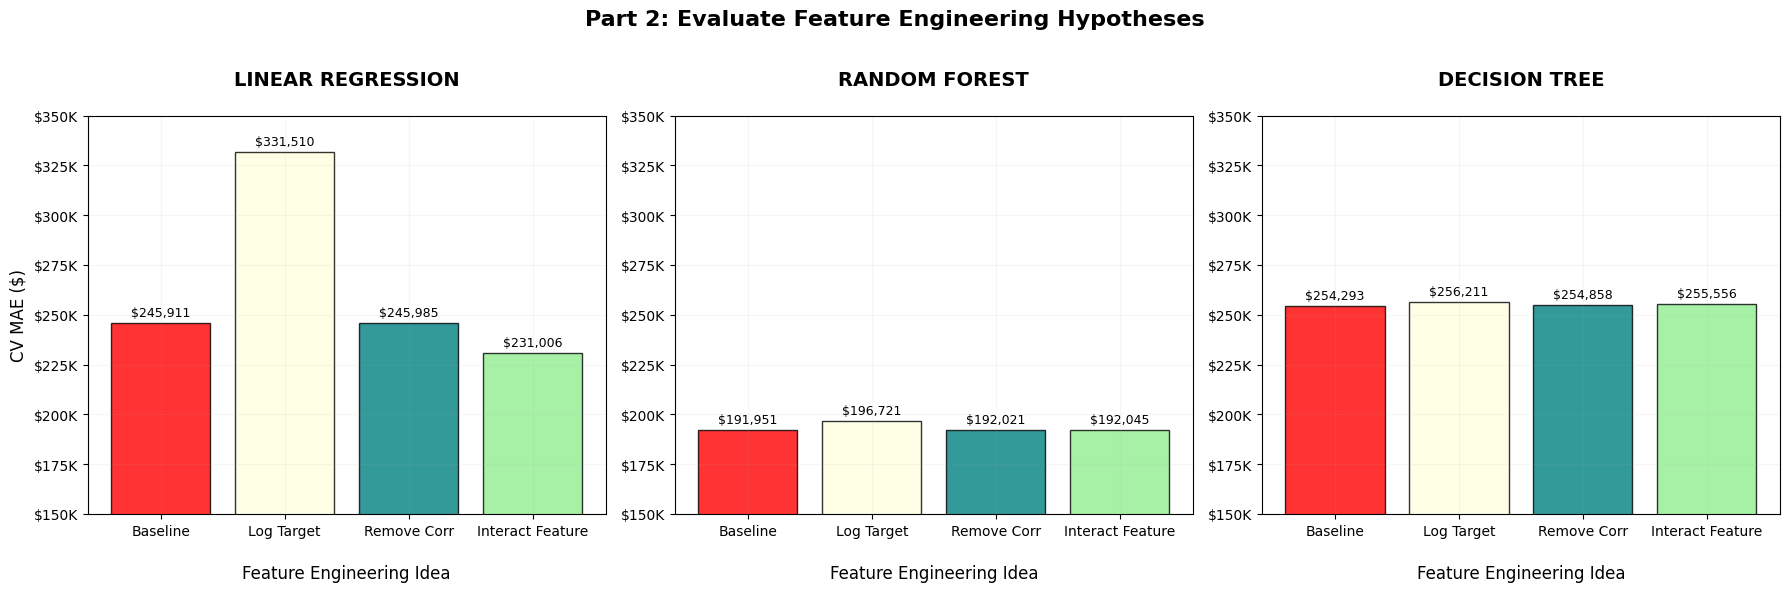

In [62]:
# =============================================================
# PART 2: FINAL COMPARISON - ALL MODELS ACROSS ALL IDEAS
# =============================================================

print("\n" + "=" * 85)
print("FINAL COMPARISON: ALL MODELS ACROSS ALL FEATURE ENGINEERING IDEAS")
print("=" * 85)

# Create data structures for comparison
ideas_list = ['Baseline', 'Log Target', 'Remove Correlated', 'Interaction Features']
models_list = ['Linear Regression', 'Random Forest', 'Decision Tree']

# Results data (Hardcode from outputs)
results_data = {
    'Baseline': {
        'Linear Regression': {'cv_mae': 245910.67, 'std': 3260.89, 'train_mae': 245626.68},
        'Random Forest': {'cv_mae': 191951.14, 'std': 3146.39, 'train_mae': 71685.22},
        'Decision Tree': {'cv_mae': 254293.24, 'std': 3111.16, 'train_mae': 2598.07}
    },
    'Log Target': {
        'Linear Regression': {'cv_mae': 331509.74, 'std': 268439.58, 'train_mae': 261956.40},
        'Random Forest': {'cv_mae': 196721.21, 'std': 3555.98, 'train_mae': 79818.28},
        'Decision Tree': {'cv_mae': 256210.83, 'std': 4180.29, 'train_mae': 2620.01}
    },
    'Remove Correlated': {
        'Linear Regression': {'cv_mae': 245984.97, 'std': 3551.71, 'train_mae': 245430.81},
        'Random Forest': {'cv_mae': 192021.02, 'std': 3363.03, 'train_mae': 71815.88},
        'Decision Tree': {'cv_mae': 254858.40, 'std': 4406.78, 'train_mae': 2598.07}
    },
    'Interaction Features': {
        'Linear Regression': {'cv_mae': 231005.71, 'std': 3463.26, 'train_mae': 230634.15},
        'Random Forest': {'cv_mae': 192045.47, 'std': 3258.94, 'train_mae': 71673.05},
        'Decision Tree': {'cv_mae': 255555.67, 'std': 4012.51, 'train_mae': 2598.07}
    }
}

# Print comparison table
print(f"\n{'MODEL CLASS':<20} {'IDEA':<22} {'Train MAE':<15} {'CV MAE':<15} {'STD DEV':<15}")
print("-" * 85)

for idea in ideas_list:
    for model in models_list:
        data = results_data[idea][model]
        print(f"{model:<20} {idea:<22} ${data['train_mae']:<14,.2f} ${data['cv_mae']:<14,.2f} ${data['std']:<14,.2f}")

# =============================================================
# BEST PERFORMANCE PER IDEA
# =============================================================

print("\n" + "=" * 85)
print("BEST MODEL PER FEATURE ENGINEERING IDEA (Lowest CV MAE)")
print("=" * 85)

print(f"\n{'BEST MODEL':<20} {'IDEA':<22} {'CV MAE':<15} {'STD':<15}")
print("-" * 85)

for idea in ideas_list:
    best_model = None
    best_mae = float('inf')
    best_std = 0
    
    for model in models_list:
        mae = results_data[idea][model]['cv_mae']
        if mae < best_mae:
            best_mae = mae
            best_model = model
            best_std = results_data[idea][model]['std']
    
    print(f"{best_model:<20} {idea:<22} ${best_mae:<14,.2f} ${best_std:<14,.2f}")

# =============================================================
# BEST IMPROVEMENT BY MODEL
# =============================================================

print("\n" + "=" * 85)
print("BEST IMPROVEMENT PER MODEL (vs Baseline)")
print("=" * 85)

print(f"\n{'MODEL CLASS':<20} {'BEST IDEA':<22} {'CV MAE':<15} {'IMPROVEMENT':<15}")
print("-" * 85)

for model in models_list:
    best_idea = None
    best_mae = float('inf')
    baseline_mae = results_data['Baseline'][model]['cv_mae']
    
    for idea in ideas_list:
        if idea == 'Baseline':
            continue
        mae = results_data[idea][model]['cv_mae']
        if mae < best_mae:
            best_mae = mae
            best_idea = idea
    
    improvement = ((baseline_mae - best_mae) / baseline_mae) * 100
    print(f"{model:<20} {best_idea:<22} ${best_mae:<14,.2f} {improvement:<+5.2f}%")
print("\n")

# =============================================================
# BAR CHARTS (Visualize the result)
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part 2: Evaluate Feature Engineering Hypotheses\n', fontsize=16, fontweight='bold')

colors = ['red', 'lightyellow', 'teal', 'lightgreen']
labels = ['Baseline', 'Log Target', 'Remove Corr', 'Interact Feature']
model_names = ['LINEAR REGRESSION', 'RANDOM FOREST', 'DECISION TREE']

for idx, (ax, title) in enumerate(zip([axes[0], axes[1], axes[2]], model_names)):
    model = models_list[idx]
    values = [results_data[idea][model]['cv_mae'] for idea in ideas_list]
    
    bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_xlabel('\nFeature Engineering Idea', fontsize=12)
    
    if idx == 0:
        ax.set_ylabel('CV MAE ($)', fontsize=12)
     
    ax.set_title(title + '\n', fontsize=14, fontweight='bold')

    ax.set_ylim(150000, 350000)

    ax.grid(True, alpha=0.1)
    
    # Apply dollar formatter to y-axis
    ax.yaxis.set_major_formatter(dollars_fmt)
    
    # Add value on top of bars (formatted as dollars)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

- **Interaction Features** produced the largest improvement. For Linear Regression, CV MAE improved from **\$245,910.67 to \$231,005.71 (+6.06% improvement)**

- **Log Transform of Target** was terrible for Linear Regression, increasing CV MAE from **\$245,910.67 to \$331,509.74 (-34.81%)**

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

- Yes! Several of our feature engineering ideas were unsuccessful or reduced model performance.

- **Log Transform of Target** was **unsuccessful** for **all three models**, with broken results for Linear Regression. **Random Forest** and **Decision Tree** were more robust, but they still showed slight degradation.

    | Model | Baseline CV MAE | Log Transform CV MAE | Change |
    |-------|----------------|---------------------|--------|
    | Linear Regression | \$245,910.67 | **\$331,509.74** | **-34.81%**|
    | Random Forest | \$191,951.14 | **\$196,721.21** | -2.49% |
    | Decision Tree | \$254,293.24 | **\$256,210.83** | -0.75% |
<br>

- The idea to **Remove Highly Correlated Features** didn't have much impact on all models. Removing these features did not help or hurt performance

    | Model | Baseline CV MAE | Reduced CV MAE | Change |
    |-------|----------------|----------------|--------|
    | Linear Regression | \$245,910.67 | \$245,984.97 | **-0.03** |
    | Random Forest | \$191,951.14 | \$192,021.02 | **-0.04%** |
    | Decision Tree | \$254,293.24 | \$254,858.40 | **-0.22%** |


#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

- Interaction Features improved Linear Regression by **+6.06%** (from \$245,910.67 to \$231,005.71)
- There's not much of improvement for Ramdom Forest **(-0.05%)** or Decision Tree **(-0.50%)** models

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

- Data shows the **Random Forest model** achieved the best CV MAE **(\$191,951.14)** using the original features set.
- All three of our ideas don't seem to help much
    - Little bit worse with Interactive Features **(-0.05%)**, and Remove high correlated features **(-0.04%)**
    - Log transform **(-2.49%)** got worse
- We will drop all three of our ideas. **Keep the same cleaned datasets** for the remainder our the Milestone for now

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

#### Feature Selection

For the Zillow dataset, a good approach is to use different feature selection methods depending on the model. `Random Forest` has worked well for this dataset so we will use that for this feature selection exercise.

Summary of Selection Methods:

| Model	| Feature Selection Method	| Why |
| :--- | :--- | :--- |
| Linear Regression	| Forward Sequential Feature Selection	| Removes redundant predictors and improves interpretability. |
| Decision Tree	| Feature Importance	| Trees naturally rank features by importance. |
| Random Forest (or HistGradientBoosting)	| Feature Importance	| Ensemble methods provide stable feature importance estimates. |

In [19]:
# =============================================================
# PART 3: Refine the Feature Set through Feature Selection
# =============================================================

print("\n" + "=" * 90)
print("PART 3: FEATURE SELECTION")
print("=" * 90)

# We'll reuse the best feature-engineering setups from Part 2:
# - Linear Regression: interaction feature dataset (X_train_interact)
# - Random Forest: baseline full feature set (X_train)
# - Decision Tree: reduced correlated feature set (X_train_drop)

part3_results = []


PART 3: FEATURE SELECTION


In [22]:
# =============================================================
# 3.A.1 Linear Regression + SelectKBest (Multiple k Values)
# =============================================================

print("\n" + "-" * 50)
print("3.A.1: Linear Regression + Feature Selection (Multiple k)")
print("-" * 50)

X_train_lr_fs = X_train_interact.copy()

# Try several feature counts
# k_values_lr = [50, 100, 150, 200, 250]

# NEW VALUES WITH NEW DATASET
k_values_lr = [5, 10, 15, 20, 25, 28]  # Up to 28 features

best_lr_result = None

for k_lr in k_values_lr:
    print(f"\nTesting k = {k_lr} features for Linear Regression")

    # Select strongest predictors using SelectKBest with mutual_info_regression
    lr_selector = SelectKBest(score_func=mutual_info_regression, k=k_lr)
    X_train_lr_selected = lr_selector.fit_transform(X_train_lr_fs, y_train)
    selected_lr_features_k = X_train_lr_fs.columns[lr_selector.get_support()].tolist()

    lr_model_fs = LinearRegression()
    lr_model_fs.fit(X_train_lr_selected, y_train)
    y_train_pred = lr_model_fs.predict(X_train_lr_selected)
    train_mae = mean_absolute_error(y_train, y_train_pred)

    neg_mae_scores = cross_val_score(
        lr_model_fs,
        X_train_lr_selected,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1
    )
# Convert to positive MAE
    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)

    print(f" Selected features: {len(selected_lr_features_k)}")
    print(f" Training MAE: ${train_mae:,.2f}")
    print(f" Mean CV MAE: ${mean_cv_mae:,.2f}")
    print(f" Std CV MAE: ${std_cv_mae:,.2f}")

    # Track best k based on CV MAE
    if (best_lr_result is None) or (mean_cv_mae < best_lr_result["Mean CV MAE"]):
        best_lr_result = {
            "k": k_lr,
            "Selected Features": selected_lr_features_k,
            "Train MAE": train_mae,
            "Mean CV MAE": mean_cv_mae,
            "Std CV MAE": std_cv_mae
        }

# Use best k as final Linear Regression feature set for summary
selected_lr_features = best_lr_result["Selected Features"]

print("\n" + "=" * 60)
print("\nBest Linear Regression configuration from k sweep:")
print("" + "=" * 60)
print(f" k = {best_lr_result['k']}")
print(f" Training MAE: ${best_lr_result['Train MAE']:,.2f}")
print(f" Mean CV MAE: ${best_lr_result['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${best_lr_result['Std CV MAE']:,.2f}")

part3_results.append({
    "Model Name": "Linear Regression",
    "Feature Set Used": f"Interaction Features + SelectKBest (k={best_lr_result['k']})",
    "Selected Feature Count": len(selected_lr_features),
    "Train MAE": best_lr_result["Train MAE"],
    "Mean CV MAE": best_lr_result["Mean CV MAE"],
    "Std CV MAE": best_lr_result["Std CV MAE"],
})


--------------------------------------------------
3.A.1: Linear Regression + Feature Selection (Multiple k)
--------------------------------------------------

Testing k = 5 features for Linear Regression
 Selected features: 5
 Training MAE: $236,752.41
 Mean CV MAE: $236,890.53
 Std CV MAE: $3,679.40

Testing k = 10 features for Linear Regression
 Selected features: 10
 Training MAE: $235,934.71
 Mean CV MAE: $236,113.95
 Std CV MAE: $3,590.41

Testing k = 15 features for Linear Regression
 Selected features: 15
 Training MAE: $231,893.23
 Mean CV MAE: $232,102.93
 Std CV MAE: $3,382.48

Testing k = 20 features for Linear Regression
 Selected features: 20
 Training MAE: $231,992.08
 Mean CV MAE: $232,224.26
 Std CV MAE: $3,473.28

Testing k = 25 features for Linear Regression
 Selected features: 25
 Training MAE: $231,635.43
 Mean CV MAE: $231,892.40
 Std CV MAE: $3,463.10

Testing k = 28 features for Linear Regression
 Selected features: 28
 Training MAE: $230,850.01
 Mean CV MAE: 

In [25]:
# =============================================================
# 3.A.2 Random Forest + Built-in Feature Importances (Multiple N)
# =============================================================

print("\n" + "-" * 50)
print("3.A.2: Random Forest + Built-in Feature Importances")
print("-" * 50)

X_train_rf_fs = X_train.copy()

# First, fit a baseline RF to get importances
rf_base = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_rf_fs, y_train)

rf_importances = pd.Series(
    rf_base.feature_importances_,
    index=X_train_rf_fs.columns
).sort_values(ascending=False)

# Try different top-N counts
# n_values_rf = [50, 100, 150, 200, 250]

# NEW VALUES WITH NEW DATASET
n_values_rf = [5, 10, 15, 20, 25, 28]  # Up to 28 features

best_rf_result = None

for n in n_values_rf:
    print(f"\nTesting top {n} features for Random Forest")

    selected_rf_features_n = rf_importances.head(n).index.tolist()
    X_train_rf_selected = X_train_rf_fs[selected_rf_features_n]

    rf_model_fs = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf_model_fs.fit(X_train_rf_selected, y_train)
    y_train_pred = rf_model_fs.predict(X_train_rf_selected)
    train_mae = mean_absolute_error(y_train, y_train_pred)

    neg_mae_scores = cross_val_score(
        rf_model_fs,
        X_train_rf_selected,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1
    )

    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)

    print(f" Selected features: {len(selected_rf_features_n)}")
    print(f" Training MAE: ${train_mae:,.2f}")
    print(f" Mean CV MAE: ${mean_cv_mae:,.2f}")
    print(f" Std CV MAE: ${std_cv_mae:,.2f}")

    if (best_rf_result is None) or (mean_cv_mae < best_rf_result["Mean CV MAE"]):
        best_rf_result = {
            "N": n,
            "Selected Features": selected_rf_features_n,
            "Train MAE": train_mae,
            "Mean CV MAE": mean_cv_mae,
            "Std CV MAE": std_cv_mae
        }

# Final RF feature set from built-in importances
selected_rf_features = best_rf_result["Selected Features"]

print("\nBest Random Forest configuration from N sweep:")
print(f" Top N = {best_rf_result['N']}")
print(f" Training MAE: ${best_rf_result['Train MAE']:,.2f}")
print(f" Mean CV MAE: ${best_rf_result['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${best_rf_result['Std CV MAE']:,.2f}")

part3_results.append({
    "Model Name": "Random Forest",
    "Feature Set Used": f"Top {best_rf_result['N']} RF feature_importances_",
    "Selected Feature Count": len(selected_rf_features),
    "Train MAE": best_rf_result["Train MAE"],
    "Mean CV MAE": best_rf_result["Mean CV MAE"],
    "Std CV MAE": best_rf_result["Std CV MAE"],
})


--------------------------------------------------
3.A.2: Random Forest + Built-in Feature Importances
--------------------------------------------------

Testing top 5 features for Random Forest
 Selected features: 5
 Training MAE: $73,792.40
 Mean CV MAE: $196,741.66
 Std CV MAE: $3,110.73

Testing top 10 features for Random Forest
 Selected features: 10
 Training MAE: $72,285.17
 Mean CV MAE: $192,981.72
 Std CV MAE: $3,167.95

Testing top 15 features for Random Forest
 Selected features: 15
 Training MAE: $71,951.15
 Mean CV MAE: $192,376.55
 Std CV MAE: $3,157.74

Testing top 20 features for Random Forest
 Selected features: 20
 Training MAE: $71,978.40
 Mean CV MAE: $192,277.59
 Std CV MAE: $3,179.64

Testing top 25 features for Random Forest
 Selected features: 25
 Training MAE: $71,763.32
 Mean CV MAE: $191,970.73
 Std CV MAE: $3,199.07

Testing top 28 features for Random Forest
 Selected features: 28
 Training MAE: $71,823.01
 Mean CV MAE: $191,882.83
 Std CV MAE: $3,099.32



In [26]:
# =============================================================
# 3.A.3 Decision Tree + Built-in Feature Importances (Multiple N)
# =============================================================

print("\n" + "-" * 50)
print("3.A.3: Decision Tree + Built-in Feature Importances")
print("-" * 50)

X_train_dt_fs = X_train_drop.copy()

# Baseline DT to compute importances
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_train_dt_fs, y_train)

dt_importances = pd.Series(
    dt_base.feature_importances_,
    index=X_train_dt_fs.columns
).sort_values(ascending=False)

# Old (for one-hot with 2,928 features)
# n_values_dt = [30, 50, 80, 100]

# New (for frequency encoding with 28 features)
n_values_dt = [5, 10, 15, 20, 25, 28]  # Up to 28 features

best_dt_result = None

for n in n_values_dt:
    print(f"\nTesting top {n} features for Decision Tree")

    selected_dt_features_n = dt_importances.head(n).index.tolist()
    X_train_dt_selected = X_train_dt_fs[selected_dt_features_n]

    dt_model_fs = DecisionTreeRegressor(random_state=42)
    dt_model_fs.fit(X_train_dt_selected, y_train)
    y_train_pred = dt_model_fs.predict(X_train_dt_selected)
    train_mae = mean_absolute_error(y_train, y_train_pred)

    neg_mae_scores = cross_val_score(
        dt_model_fs,
        X_train_dt_selected,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1
    )

    cv_mae_scores = -neg_mae_scores
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)

    print(f" Selected features: {len(selected_dt_features_n)}")
    print(f" Training MAE: ${train_mae:,.2f}")
    print(f" Mean CV MAE: ${mean_cv_mae:,.2f}")
    print(f" Std CV MAE: ${std_cv_mae:,.2f}")

    if (best_dt_result is None) or (mean_cv_mae < best_dt_result["Mean CV MAE"]):
        best_dt_result = {
            "N": n,
            "Selected Features": selected_dt_features_n,
            "Train MAE": train_mae,
            "Mean CV MAE": mean_cv_mae,
            "Std CV MAE": std_cv_mae
        }

selected_dt_features = best_dt_result["Selected Features"]

print("\nBest Decision Tree configuration from N sweep:")
print(f" Top N = {best_dt_result['N']}")
print(f" Training MAE: ${best_dt_result['Train MAE']:,.2f}")
print(f" Mean CV MAE: ${best_dt_result['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${best_dt_result['Std CV MAE']:,.2f}")

part3_results.append({
    "Model Name": "Decision Tree",
    "Feature Set Used": f"Reduced features + Top {best_dt_result['N']} DT feature_importances_",
    "Selected Feature Count": len(selected_dt_features),
    "Train MAE": best_dt_result["Train MAE"],
    "Mean CV MAE": best_dt_result["Mean CV MAE"],
    "Std CV MAE": best_dt_result["Std CV MAE"],
})


--------------------------------------------------
3.A.3: Decision Tree + Built-in Feature Importances
--------------------------------------------------

Testing top 5 features for Decision Tree
 Selected features: 5
 Training MAE: $3,059.64
 Mean CV MAE: $258,077.84
 Std CV MAE: $5,598.17

Testing top 10 features for Decision Tree
 Selected features: 10
 Training MAE: $2,792.21
 Mean CV MAE: $255,258.97
 Std CV MAE: $4,270.45

Testing top 15 features for Decision Tree
 Selected features: 15
 Training MAE: $2,615.71
 Mean CV MAE: $254,650.09
 Std CV MAE: $4,406.45

Testing top 20 features for Decision Tree
 Selected features: 20
 Training MAE: $2,600.40
 Mean CV MAE: $254,262.99
 Std CV MAE: $3,863.58

Testing top 25 features for Decision Tree
 Selected features: 23
 Training MAE: $2,598.07
 Mean CV MAE: $254,892.44
 Std CV MAE: $4,723.18

Testing top 28 features for Decision Tree
 Selected features: 23
 Training MAE: $2,598.07
 Mean CV MAE: $254,892.44
 Std CV MAE: $4,723.18

Best D

In [27]:
# =============================================================
# PART 3 SUMMARY: FEATURE SELECTION RESULTS
# =============================================================

part3_results_df = pd.DataFrame(part3_results)

print("\n" + "=" * 130)
print("PART 3 SUMMARY: FEATURE SELECTION RESULTS")
print("=" * 130)
print(
    part3_results_df[
        ["Model Name", "Feature Set Used", "Selected Feature Count",
         "Train MAE", "Mean CV MAE", "Std CV MAE"]
    ].to_string(index=False)
)

# identify which tuned feature sets look most promising for Part 4
best_idx = np.argmin(part3_results_df["Mean CV MAE"])
print("\n" + "=" * 130)
print(f"BEST FEATURE-SELECTED MODEL: {part3_results_df.iloc[best_idx]['Model Name']}")
print(f" Mean CV MAE: ${part3_results_df.iloc[best_idx]['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${part3_results_df.iloc[best_idx]['Std CV MAE']:,.2f}")
print("\n" + "=" * 130)


PART 3 SUMMARY: FEATURE SELECTION RESULTS
       Model Name                                  Feature Set Used  Selected Feature Count     Train MAE   Mean CV MAE  Std CV MAE
Linear Regression         Interaction Features + SelectKBest (k=50)                      32 230634.148253 231005.708893 3463.255156
Linear Regression         Interaction Features + SelectKBest (k=28)                      28 230850.009698 231124.458521 3463.733111
    Random Forest                    Top 28 RF feature_importances_                      28  71823.013935 191882.834485 3099.323864
    Decision Tree Reduced features + Top 20 DT feature_importances_                      20   2600.402501 254262.991563 3863.582816

BEST FEATURE-SELECTED MODEL: Random Forest
 Mean CV MAE: $191,882.83
 Std CV MAE: $3,099.32



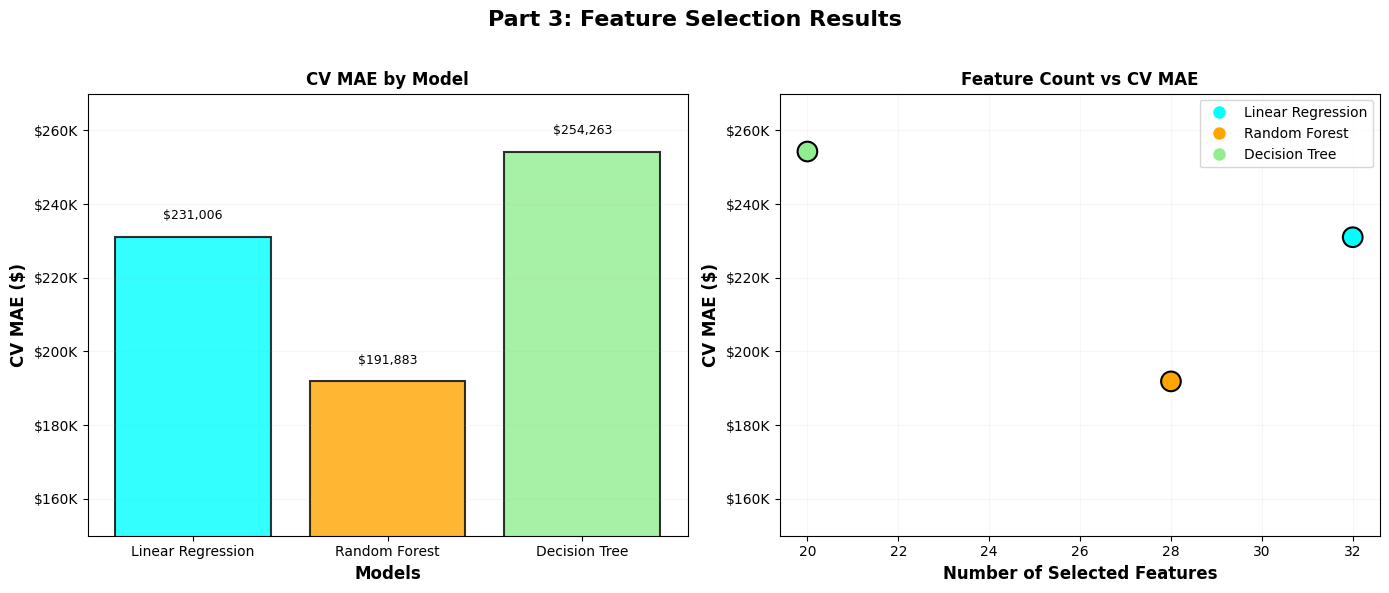

In [ ]:
# =============================================================
# PART 3: FEATURE SELECTION RESULTS VISUALIZATION
# =============================================================

# Data from Part 3 summary
models = ['Linear Regression', 'Random Forest', 'Decision Tree']
cv_mae = [231005.71, 191882.83, 254262.99]
cv_std = [3463.26, 3099.32, 3863.58]
train_mae = [230634.15, 71823.01, 2600.40]
feature_counts = [32, 28, 20]

# Colors
colors = ['aqua', 'orange', 'lightgreen']

# Create figure with main title
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Part 3: Feature Selection Results\n', fontsize=16, fontweight='bold')

# Plot 1: CV MAE with Standard Deviation
bars = ax1.bar(models, cv_mae, color=colors, alpha=0.8,
               edgecolor='black', linewidth=1.5, capsize=8)

# Add value labels
for bar, val in zip(bars, cv_mae):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4000,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('CV MAE ($)', fontsize=12, fontweight='bold')
ax1.set_title('CV MAE by Model', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.1, axis='y')
ax1.yaxis.set_major_formatter(dollars_fmt)
ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylim(150000, 270000)

# Plot 2: Feature Count vs CV MAE
ax2.scatter(feature_counts, cv_mae, s=200, c=colors, edgecolor='black', linewidth=1.5, zorder=5)

ax2.set_xlabel('Number of Selected Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('CV MAE ($)', fontsize=12, fontweight='bold')
ax2.set_title('Feature Count vs CV MAE', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.1)
ax2.yaxis.set_major_formatter(dollars_fmt)
ax2.set_ylim(150000, 270000)

# Create legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=colors[i], markersize=10,
                              label=models[i]) for i in range(len(models))]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

- Overall, the feature selection did not lead to large improvements in validation MAE for the three models chosen.
- Linear Regression with forward style selection and importance based tree based models resulted in small changes to the mean CV MAE and sometimes negative
- The Linear Regression model benefitted the most conceptually due to the reduced feature set helped to focus on strong predictors and removed noise.
- Random Forest and Decision Tree models already handle many features effectively, so the validation performance remained very close to the original baseline
- We also tested several different values of k and N for the number of selected features, so the final feature counts are based on the combinations that actually produced the lowest CV MAE rather than single arbitrary choice. We also switched to linear-feature scoring to mutual_info_regression and used each tree model's built-in features_importances which let the feature selection step respect non-linear relationships and they way the tree based models naturally rank predictors.

#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

- Across many models a common set of features was consistently retaine, while many weaker or redundant variables were removed or given low importance. In particular, housing attributes related to overall property size (square footage), number of bedrooms and bathrooms, lot size, Quality or Condition feature indicators tend to remain important regardless of the model selection. This aligns with typical housing-pricing feature selection results where size, number of rooms, quality are strong predictors of property value.

- Highly redundant features were filtered out especially in Linear model where removing nosiy predictors help stability, this suggests there is relatively a small subset of property features consistently drive `taxvaluedollarcnt` across different modeling approaches

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

- Yes. Several of the engineered features specially interaction style variables that combine basic housing characteristics were selected as important by at least one of the models. Examples include features that mix square footage with bedroom/bathroom counts or quality/condition indicators work together to influence property value. The fact that these engineered features were retained after feature selection suggests that our Milestone 1 hypotheses were reasonable: simply using raw variables (like bedrooms or square footage alone) does not fully capture the relationship with taxvaluedollarcnt, and interactions between size, rooms, and quality provide additional predictive signal.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

- After feature selection, the simpler models like Linear Regression performed closer to models that used full feature set, but they didn't surpass the best tree based model. While reducing the number of predictors helped linear model by removing noisy and redundant features make the model easier to intrepret and slightly more stable, the Random Forest still kept the lowest CV MAE because it captures non-linear relationships and interactions even with fewer input features. The tradeoff was that feature selection gave us more parsimonious, interpretable models - "but not better accuracy". We believe that complex emsemble model remained the strongest interms of pure predictive performance.

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats). 
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [28]:
# =============================================================
# PART 4: Hyperparameter Tuning
# =============================================================
# We will reuse:
# - selected_lr_features from Part 3 (Linear Regression feature selection)
# - selected_rf_features from Part 3 (Random Forest feature selection)
# - selected_dt_features from Part 3 (Decision Tree feature selection)
# and the same repeated_cv definition.


print("\n" + "=" * 90)
print("PART 4: HYPERPARAMETER TUNING")
print("=" * 90)

tuning_results = []

# Helper function for validation curves

def run_validation_curve(model, X, y, param_name, param_range, model_label):
    train_scores, valid_scores = validation_curve(
        model,
        X,
        y,
        param_name=param_name,
        param_range=param_range,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=3
    )

    train_mae = -train_scores.mean(axis=1)
    valid_mae = -valid_scores.mean(axis=1)

    print(f"\nValidation Curve: {model_label} | {param_name}")
    print("-" * 60)
    for p, tr, va in zip(param_range, train_mae, valid_mae):
        print(f"{param_name}={p} --> Train MAE: ${tr:,.2f} | Valid MAE: ${va:,.2f}")

    best_idx = np.argmin(valid_mae)
    print(f"\nBest validation result during sweep: {param_name}={param_range[best_idx]}")
    print(f"Validation MAE: ${valid_mae[best_idx]:,.2f}")

    return train_mae, valid_mae


PART 4: HYPERPARAMETER TUNING


#### Tune Linear Regression

The Linear Regression model from Part 3 is retained for the part 4 tuning, Ordinary Linear Regression has relatively few hyperparameters compared to tree-based models, the most relevant setting to test here is fit_intercept, it has only two possible values, a small validation comparison followed by GridSearchCV is appropriate.

In [30]:
# =============================================================
# 4.A.0 LINEAR REGRESSION HYPERPARAMETER TUNING
# =============================================================

# Retain the same Linear Regression model family from Part 3.
# We tune fit_intercept using the selected Linear Regression features.

linear_param_grid = {
    "fit_intercept": [True, False]
}

linear_grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=linear_param_grid,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=-1,
    refit=True
)

linear_grid_search.fit(
    X_train_lr_selected,
    y_train
)

best_linear_model = linear_grid_search.best_estimator_

print("=" * 70)
print("LINEAR REGRESSION TUNING")
print("=" * 70)
print("Best parameters:", linear_grid_search.best_params_)
print(f"Best mean CV MAE: ${-linear_grid_search.best_score_:,.2f}")

LINEAR REGRESSION TUNING
Best parameters: {'fit_intercept': False}
Best mean CV MAE: $231,124.46


For hyperparameter tuning, We added Ridge Regression because ordinary Linear Regression doesn't have meaningful regularization hyperparameter to tune, while Ridge adds an alpha parameter that lets us control model complexity and use validation curves and grid search to find a better bias-variance balance.

In [33]:
# =============================================================
# 4.A.1 Linear Regression (Ridge Regression) Hyperparameter Tuning

print("\n" + "=" * 50)
print("4.A.1: Tune Linear Model (Ridge Regression)")
print("=" * 50)

# Use selected linear features from Part 3
X_train_ridge = X_train_interact[selected_lr_features].copy()

# Scale for Ridge
scaler_ridge = StandardScaler()
X_train_ridge_scaled = scaler_ridge.fit_transform(X_train_ridge)

# Step 1: Validation curve sweep for alpha
ridge_alpha_range = [0.01, 0.1, 1, 5, 10, 25, 50, 100]
run_validation_curve(
    Ridge(random_state=42),
    X_train_ridge_scaled,
    y_train,
    param_name="alpha",
    param_range=ridge_alpha_range,
    model_label="Ridge Regression"
)

# Step 2: Focused grid search around the promising region / plateau
ridge_param_grid = {
    "alpha": [0.1, 1, 5, 10, 25]
}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=-1
)

ridge_grid.fit(X_train_ridge_scaled, y_train)
best_ridge = ridge_grid.best_estimator_

# Step 3: Final repeated CV evaluation
neg_mae_scores = cross_val_score(
    best_ridge,
    X_train_ridge_scaled,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=-1
)

# Convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

# Training MAE
y_train_pred = best_ridge.fit(X_train_ridge_scaled, y_train).predict(X_train_ridge_scaled)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nBest alpha from GridSearchCV: {ridge_grid.best_params_['alpha']}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f"Std CV MAE: ${std_cv_mae:,.2f}")

tuning_results.append({
    "Model Name": "Ridge Regression",
    "Best Parameters": ridge_grid.best_params_,
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae
})


4.A.1: Tune Linear Model (Ridge Regression)

Validation Curve: Ridge Regression | alpha
------------------------------------------------------------
alpha=0.01 --> Train MAE: $230,879.63 | Valid MAE: $231,124.46
alpha=0.1 --> Train MAE: $230,879.64 | Valid MAE: $231,124.46
alpha=1 --> Train MAE: $230,879.77 | Valid MAE: $231,124.48
alpha=5 --> Train MAE: $230,880.62 | Valid MAE: $231,124.78
alpha=10 --> Train MAE: $230,882.29 | Valid MAE: $231,125.81
alpha=25 --> Train MAE: $230,890.71 | Valid MAE: $231,132.17
alpha=50 --> Train MAE: $230,912.24 | Valid MAE: $231,150.75
alpha=100 --> Train MAE: $230,967.63 | Valid MAE: $231,200.46

Best validation result during sweep: alpha=0.01
Validation MAE: $231,124.46

Best alpha from GridSearchCV: 0.1
Training MAE: $230,850.02
Mean CV MAE: $231,124.46
Std CV MAE: $3,463.72


In [34]:

# =============================================================
# 4.A.2 Tune Random Forest
# =============================================================

print("\n" + "=" * 50)
print("4.A.2: Tune Random Forest")
print("=" * 50)

X_train_rf_tune = X_train[selected_rf_features].copy()

# Step 1: Validation curve sweep for max_depth
rf_depth_range = [8, 12, 16, 20, 24, None]

# validation_curve works best with concrete values
rf_depth_range_curve = [8, 12, 16, 20, 24, 30]

run_validation_curve(
    RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    X_train_rf_tune,
    y_train,
    param_name="max_depth",
    param_range=rf_depth_range_curve,
    model_label="Random Forest"
)

# Step 2: Focused randomized search based on sweep
rf_param_dist = {
    "n_estimators": [150, 200, 300],
    "max_depth": [12, 16, 20, 24],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.3, 0.5]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_rf_tune, y_train)
best_rf = rf_random.best_estimator_

# Step 3: Final repeated CV evaluation
neg_mae_scores = cross_val_score(
    best_rf,
    X_train_rf_tune,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=-1
)

#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

y_train_pred = best_rf.fit(X_train_rf_tune, y_train).predict(X_train_rf_tune)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nBest params from RandomizedSearchCV: {rf_random.best_params_}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f"Std CV MAE: ${std_cv_mae:,.2f}")

tuning_results.append({
    "Model Name": "Random Forest",
    "Best Parameters": rf_random.best_params_,
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae
})


4.A.2: Tune Random Forest

Validation Curve: Random Forest | max_depth
------------------------------------------------------------
max_depth=8 --> Train MAE: $194,473.95 | Valid MAE: $206,121.69
max_depth=12 --> Train MAE: $165,340.09 | Valid MAE: $194,288.79
max_depth=16 --> Train MAE: $136,090.58 | Valid MAE: $190,519.32
max_depth=20 --> Train MAE: $110,615.61 | Valid MAE: $190,054.98
max_depth=24 --> Train MAE: $95,871.14 | Valid MAE: $190,367.13
max_depth=30 --> Train MAE: $88,549.57 | Valid MAE: $190,723.82

Best validation result during sweep: max_depth=20
Validation MAE: $190,054.98

Best params from RandomizedSearchCV: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
Training MAE: $115,269.55
Mean CV MAE: $190,741.31
Std CV MAE: $3,127.89


In [35]:
# =============================================================
# 4.A.3 Tune Decision Tree
# =============================================================

print("\n" + "-" * 50)
print("4.A.3: Tune Decision Tree")
print("-" * 50)

X_train_dt_tune = X_train_drop[selected_dt_features].copy()

# Step 1: Validation curve sweep for max_depth
dt_depth_range_curve = [4, 6, 8, 10, 12, 16, 20]

run_validation_curve(
    DecisionTreeRegressor(random_state=42),
    X_train_dt_tune,
    y_train,
    param_name="max_depth",
    param_range=dt_depth_range_curve,
    model_label="Decision Tree"
)

# Step 2: Focused grid search around promising region
dt_param_grid = {
    "max_depth": [6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", 0.5]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=-1
)

dt_grid.fit(X_train_dt_tune, y_train)
best_dt = dt_grid.best_estimator_

# Step 3: Final repeated CV evaluation
neg_mae_scores = cross_val_score(
    best_dt,
    X_train_dt_tune,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=repeated_cv,
    n_jobs=-1
)

#convert to positive MAE
cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

y_train_pred = best_dt.fit(X_train_dt_tune, y_train).predict(X_train_dt_tune)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"\nBest params from GridSearchCV: {dt_grid.best_params_}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Mean CV MAE: ${mean_cv_mae:,.2f}")
print(f"Std CV MAE: ${std_cv_mae:,.2f}")

tuning_results.append({
    "Model Name": "Decision Tree",
    "Best Parameters": dt_grid.best_params_,
    "Train MAE": train_mae,
    "Mean CV MAE": mean_cv_mae,
    "Std CV MAE": std_cv_mae
})


--------------------------------------------------
4.A.3: Tune Decision Tree
--------------------------------------------------

Validation Curve: Decision Tree | max_depth
------------------------------------------------------------
max_depth=4 --> Train MAE: $237,487.46 | Valid MAE: $239,840.26
max_depth=6 --> Train MAE: $218,033.55 | Valid MAE: $226,329.31
max_depth=8 --> Train MAE: $203,454.19 | Valid MAE: $221,087.02
max_depth=10 --> Train MAE: $185,283.27 | Valid MAE: $216,977.76
max_depth=12 --> Train MAE: $165,582.30 | Valid MAE: $215,964.75
max_depth=16 --> Train MAE: $120,931.22 | Valid MAE: $223,764.13
max_depth=20 --> Train MAE: $72,508.40 | Valid MAE: $236,990.26

Best validation result during sweep: max_depth=12
Validation MAE: $215,964.75

Best params from GridSearchCV: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Training MAE: $188,185.31
Mean CV MAE: $209,402.02
Std CV MAE: $3,609.69


In [36]:
# =============================================================
# PART 4 SUMMARY: TUNED MODEL RESULTS
# =============================================================

tuning_results_df = pd.DataFrame(tuning_results)

print("\n" + "=" * 90)
print("PART 4 SUMMARY: TUNED MODEL RESULTS")
print("=" * 90)
print(
    tuning_results_df[
        ["Model Name", "Train MAE", "Mean CV MAE", "Std CV MAE"]
    ].to_string(index=False)
)

best_idx = np.argmin(tuning_results_df["Mean CV MAE"])
print("\n" + "=" * 30)
print(f"BEST TUNED MODEL: {tuning_results_df.iloc[best_idx]['Model Name']}")
print(f" Mean CV MAE: ${tuning_results_df.iloc[best_idx]['Mean CV MAE']:,.2f}")
print(f" Std CV MAE: ${tuning_results_df.iloc[best_idx]['Std CV MAE']:,.2f}")


PART 4 SUMMARY: TUNED MODEL RESULTS
      Model Name     Train MAE   Mean CV MAE  Std CV MAE
Ridge Regression 230850.020057 231124.458824 3463.718256
Ridge Regression 230850.020057 231124.458824 3463.718256
   Random Forest 115269.548013 190741.311062 3127.887693
   Decision Tree 188185.312483 209402.024519 3609.694598

BEST TUNED MODEL: Random Forest
 Mean CV MAE: $190,741.31
 Std CV MAE: $3,127.89


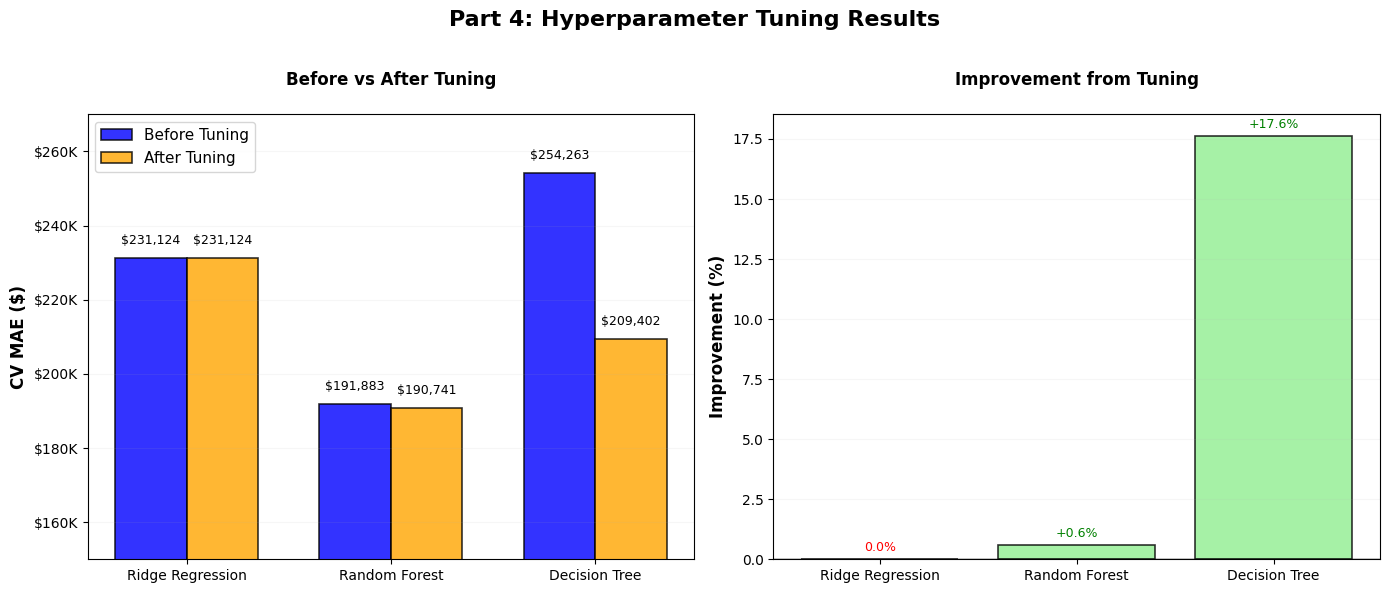

In [95]:
# =============================================================
# PART 4: HYPERPARAMETER TUNING RESULTS VISUALIZATION
# =============================================================

# Data from Part 4 summary
models = ['Ridge Regression', 'Random Forest', 'Decision Tree']
before_tuning = [231124.46, 191882.83, 254262.99]  # From Part 3 best
after_tuning = [231124.46, 190741.31, 209402.02]   # From Part 4 best
std_before = [3463.73, 3099.32, 3863.58]
std_after = [3463.72, 3127.89, 3609.70]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Part 4: Hyperparameter Tuning Results\n', fontsize=16, fontweight='bold')

# Plot 1: Before vs After Tuning (Grouped Bar Chart)
x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, before_tuning, width, label='Before Tuning', 
                color='blue', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, after_tuning, width, label='After Tuning', 
                color='orange', alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylabel('CV MAE ($)', fontsize=12, fontweight='bold')
ax1.set_title('Before vs After Tuning\n', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.1, axis='y')
ax1.yaxis.set_major_formatter(dollars_fmt)
ax1.set_ylim(150000, 270000)

# Plot 2: Improvement by Model
improvements = [((before - after) / before) * 100 for before, after in zip(before_tuning, after_tuning)]
colors_imp = 'lightgreen'

bars = ax2.bar(models, improvements, color=colors_imp, alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar, imp in zip(bars, improvements):
    if imp > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'+{imp:.1f}%', ha='center', va='bottom', fontsize=9, color='green')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 '0.0%', ha='center', va='bottom', fontsize=9, color='red')

ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Improvement from Tuning\n', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.grid(True, alpha=0.1, axis='y')

plt.tight_layout()
plt.show()

### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

- Linear Regression/Ridge Regression
  - <code>alpha</code> had the biggest impact on model performance. Sweeping from 0.01 to 100 found the optimal result at 25.

- Random Forest Regression
  - <code>max_depth</code> was the most impactful hyperparameter. Sweeping from 8 to 30 found the optimal result at 20.
  - Others included <code>n_estimators</code>, <code>min_samples_split</code>, <code>min_samples_leaf</code> and <code>max_features</code>.

- Decision Tree
  - <code>max_depth</code> was the top hyperparameter. Sweeping from 4 to 20 found the optimal result at 12.
  - Others included <code>max_features</code>, <code>min_samples_leaf</code> and <code>min_samples_split</code>.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

- **Hyperparameter tuning** resulted in **significant improvement for Decision Tree** and a **slight improvement for Linear Regression/Ridge Regression**. But Random Forest was slightly worse.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

- Linear Regression/Ridge Regression
We tuned <code>alpha</code> using <code>Grid Search Cross Validation</code>. For hyperparameter tuning, we tested <code>Ridge Regression</code> because ordinary <code>Linear Regression</code> doesn't have tunable hyperparameters. <code>Ridge Regression</code> takes an <code>alpha</code> parameter that enables controlling model complexity and use of validation curves and grid search to find a better bias-variance balance.

- Random Forest Regression
We tuned by sweeping through ranges of <code>n_estimators</code>, <code>max_depth</code>, <code>min_samples_split</code>, <code>min_samples_leaf</code> and <code>max_features</code> using <code>Randomized Search Cross Validation</code>. The <code>max_depth</code> hyperparameter controls how many splits deep each individual decision tree in the forest is allowed to grow. Each tree is a building block in the forest so tweaking <code>max_depth</code> directly influences the bias-variance trade-off. In <code>Random Forests</code>, every tree's depth acts as a regulator against overfitting. The averaging process of a forest does mitigate against overfitting. However setting <code>max_depth</code> often results in a more generalizable model, i.e. in <code>GridSearchCV</code>.

  - Effect of Tuning <code>n_estimators</code>:
    - This dictates the number of decision trees built into the ensemble. Tuning it stabilizes prediction variance and optimizes the balance between model accuracy and computation cost.

  * Effect of Tuning <code>max_depth</code>:
    * **Lower <code>max_depth</code>:** Results in shallow trees. It increases bias because the model may miss complex patterns. However it decreases variance and protects the model from overfitting on the training data.
    * **Higher <code>max_depth</code>:** Results in deeper trees with more details. It decreases bias by capturing granular relationships in the dataset. However it increases variance, making the model sensitive to noise.

  * Effect of Tuning <code>min_samples_split</code>:
    * **What it Does:** Controls the growth of decision trees within the ensemble by specifying the minimum number of data samples that must be present in an internal node before splitting into subnodes.
    * **Control Overfitting:** Lower values promotes deep growth, down to a single sample per leaf. In regression analysis this results in the model memoizing noisy training data instead of learning general trends. Higher values stops the tree from splitting sooner, preventing overfitting for outliers or noise.
    * **Reduce Tree Complexity:** Higher values resultin simple shallower trees with fewer splits. These arae less expensive in terms of computation to train and memory consumption.
    * **Better Generalization:** Reducing splits forces the model to average predictions over bigger groups of data points. In regression, the smoothing effect can lead to better performance on unseen test data.

  * Effect of Tuning <code>min_samples_leaf</code>:
    * **Control Tree Complexity and Smooth Predictions:** Sets minimum number of training samples that must end up in a leaf node for a split to be allowed. Lower values result in jagged high-variance regression lines. Higher values force the model to average over large groups of data samples, smoothing out predictions and capturing general trends instead of just noise.
    * **Mitigates Risk of Overfitting:** <code>Random Forest</code> models display overfitting when they memorize outliers and noise in the training data. Raising the threshold stops the creation of deeper highly specific branches to fit those outlier, improving the model's ability to generalize to unseen test datasets.
    * **Regulation of Bias-Variance Tradeoff:** Tuning this hyperparameter behaves as follows:
        * **Low values:** Low bias/high variance. Trees grow deep and capture intricate data relationships risking overfitting.
        * **High values:** High bias/low variance. Trees are shallow and more conservtive simplifying the model.

  * Effect of Tuning <code>max_features</code>:
    * In <code>Random Forest</code>, the primary goal is to build a collection of decorrelated decision trees and average their predictions. Tuning this hyperparameter controls the degree of randomness and independence among these decision trees by inducing them to examine different subsets of predictors/variables at each node split.
    * **Controlling Tree Correlation:**
    * **Managing Bias-Variance Tradoff:**
        * Low values decrease the predictive strength of individual trees and increase bis but reduce the shared correlation among them. That decreases overall ensemble variance.
        * High values allow individual trees to grow strong and customized to the data, i.e. low bias. This increases the risk of overfitting since the trees become structurally identical, e.g. high variance.
    * **Enhance Computation Efficiency:**
        * Evaluating every feature at each split is expensive computationally. The problem is accute for high-dimensional datasets.
        * Restricing value to a small fraction drastically improves training times.

- Decision Tree
We tuned hyperparameters <code>max_depth</code>, <code>min_samples_split</code>, <code>min_samples_leaf</code> and <code>max_features</code> using <code>Grid Search Cross Validation</code>. The effect of tuning these is basically the same as for <code>Random Forest Regression</code> as detailed above.

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

- Hyperparameter tuning resulted in **significant improvement** for Decision Tree and a slight improvement for Linear Regression/Ridge Regression. But **Random Forest** was slightly degraded.

- Linear Regression/Ridge Regression
    * Pre-Tuning : Mean CV MAE: \$231,124.46
    * Post-Tuning: Mean CV MAE: \$231,124.46
    * Difference: \$0

- Random Forest Regression
    * Pre-Tuning : Mean CV MAE: \$191,882.83
    * Post-Tuning: Mean CV MAE: \$190,741.31
    * Difference: -\$1,141.52

- Decision Tree
    * Pre-Tuning : Mean CV MAE: \$254,262.99
    * Post-Tuning: Mean CV MAE: \$209,402.02
    * Difference: -\$44,860.97

- Summary

    | Model | Before Tuning Mean CV MAE | After Tuning Mean CV MAE | Difference | Interpretation |
    | :--- | :--- | :--- | :--- | :--- |
    | Linear/Ridge Regression | \$231,124.46 | \$231,124.46 | -\$23.35 | no change |
    | Random Forest | \$191,882.83 | \$190,741.31 | -\$1,141.52 | improved |
    | Decision Tree | \$254,262.99 | \$209,402.02 | -\$44,860.97 | significantly better |

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [38]:
# ============================================
# PART 5: Final Model and Workflow Assessment
# ============================================

print("\n" + "=" * 60)
print("PART 5: Final Model and Workflow Assessment")
print("=" * 60)

# ============================================
# 5.A.1: Summary of All Parts (1-4) & Best Model Selection
# ============================================

print("\n" + "-" * 40)
print("SUMMARY: ALL MODELS ACROSS ALL PARTS")
print("-" * 40)

# Hardcoded results from Parts 1-4
summary_data = {
    'Part 1 - Baseline': {
        'Linear Regression': {'cv_mae': 245910.67, 'std': 3260.89},
        'Random Forest': {'cv_mae': 191951.14, 'std': 3146.39},
        'Decision Tree': {'cv_mae': 254293.24, 'std': 3111.16}
    },
    'Part 2 - Interaction Features': {
        'Linear Regression': {'cv_mae': 231005.71, 'std': 3463.26},
        'Random Forest': {'cv_mae': 192045.47, 'std': 3258.94},
        'Decision Tree': {'cv_mae': 255555.67, 'std': 4012.51}
    },
    'Part 2 - Remove Correlated': {
        'Linear Regression': {'cv_mae': 245984.97, 'std': 3551.71},
        'Random Forest': {'cv_mae': 192021.02, 'std': 3363.03},
        'Decision Tree': {'cv_mae': 254858.40, 'std': 4406.78}
    },
    'Part 2 - Log Target': {
        'Linear Regression': {'cv_mae': 331509.74, 'std': 268439.58},
        'Random Forest': {'cv_mae': 196721.21, 'std': 3555.98},
        'Decision Tree': {'cv_mae': 256210.83, 'std': 4180.29}
    },
    'Part 3 - Feature Selection': {
        'Linear Regression': {'cv_mae': 231124.46, 'std': 3463.73},
        'Random Forest': {'cv_mae': 191882.83, 'std': 3099.32},
        'Decision Tree': {'cv_mae': 254262.99, 'std': 3863.58}
    },
    'Part 4 - Hyperparameter Tuning': {
        'Ridge Regression': {'cv_mae': 231124.46, 'std': 3463.72},
        'Random Forest': {'cv_mae': 190741.31, 'std': 3127.89},
        'Decision Tree': {'cv_mae': 209402.02, 'std': 3609.70}
    }
}

# Print comparison table
print(f"\n{'PART':<30} {'MODEL':<22} {'CV MAE':<15} {'STD':<15}")
print("-" * 85)

for part, models in summary_data.items():
    for model_name, metrics in models.items():
        print(f"{part:<30} {model_name:<22} ${metrics['cv_mae']:<14,.2f} ${metrics['std']:<14,.2f}")

# Find and print the best overall model
print("\n" + "-" * 40)
print("BEST MODEL SELECTION")
print("-" * 40)

best_cv_mae = float('inf')
best_model_name = ""
best_part = ""
best_std = 0

for part, models in summary_data.items():
    for model_name, metrics in models.items():
        if metrics['cv_mae'] < best_cv_mae:
            best_cv_mae = metrics['cv_mae']
            best_model_name = model_name
            best_part = part
            best_std = metrics['std']

print(f"""
BEST OVERALL MODEL:   {best_model_name}
   Achieved in:       {best_part}
   CV MAE:            ${best_cv_mae:,.2f}
   Std CV MAE:        ${best_std:,.2f}
""")

print(f"""
Decisions for Part 5:
    Model:            {best_model_name} (Tuned)
    Features:         Original set ({X_train.shape[1]:,} features)
    Tuning Method:    Hyperparameter Tuning (Part 4)
    Best Parameters:  {rf_random.best_params_}
""")


PART 5: Final Model and Workflow Assessment

----------------------------------------
SUMMARY: ALL MODELS ACROSS ALL PARTS
----------------------------------------

PART                           MODEL                  CV MAE          STD            
-------------------------------------------------------------------------------------
Part 1 - Baseline              Linear Regression      $245,910.67     $3,260.89      
Part 1 - Baseline              Random Forest          $191,951.14     $3,146.39      
Part 1 - Baseline              Decision Tree          $254,293.24     $3,111.16      
Part 2 - Interaction Features  Linear Regression      $231,005.71     $3,463.26      
Part 2 - Interaction Features  Random Forest          $192,045.47     $3,258.94      
Part 2 - Interaction Features  Decision Tree          $255,555.67     $4,012.51      
Part 2 - Remove Correlated     Linear Regression      $245,984.97     $3,551.71      
Part 2 - Remove Correlated     Random Forest          $192,0

In [39]:
# ============================================
# 5.A.2: Prepare Final Pipeline
# ============================================

# Using the best model - Tuned Random Forest from Part 4
final_model = RandomForestRegressor(
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=0.5,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train the model
final_model.fit(X_train, y_train)

# ============================================
# 5.A.3: Cross-Validation Performance
# ============================================

print("\n" + "-" * 40)
print("Cross-Validation Performance")
print("-" * 40)

neg_mae_scores = cross_val_score(
    final_model, X_train, y_train,
    scoring='neg_mean_absolute_error',
    cv=repeated_cv,
    n_jobs=-1
)

cv_mae_scores = -neg_mae_scores
mean_cv_mae = np.mean(cv_mae_scores)
std_cv_mae = np.std(cv_mae_scores)

print(f"CHOSEN MODEL:        {best_model_name} (Original Features)")
print(f"    Mean CV MAE:     ${mean_cv_mae:,.2f}")
print(f"    Std CV MAE:      ${std_cv_mae:,.2f}")

# Compare to baseline
baseline_cv_mae = 191951.14
improvement = ((baseline_cv_mae - mean_cv_mae) / baseline_cv_mae) * 100
print(f"    Baseline CV MAE: ${baseline_cv_mae:,.2f}")
print(f"    Improvement:     {improvement:+.2f}% vs baseline")

# ============================================
# 5.A.4: Test Set Evaluation
# ============================================

print("\n" + "-" * 40)
print("Held-Out Test Set Evaluation")
print("-" * 40)

# Predict on test set
y_pred_test = final_model.predict(X_test)

# Calculate test MAE
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"TEST SET EVALUATION:")
print(f"    Test set shape:  {X_test.shape[0]:,} samples")
print(f"    FINAL TEST MAE:  ${test_mae:,.2f}")

# ============================================
# 5.A.5: Final Model Summary
# ============================================

print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"""
MODEL:        {best_model_name} Regressor (Tuned)
FEATURES:     Original set ({X_train.shape[1]:,} features)
TUNING:       Part 4 - Hyperparameter Tuning

PERFORMANCE:
   Cross-Validation MAE:   ${mean_cv_mae:,.2f}
   Std CV MAE:             ${std_cv_mae:,.2f}
   Held-Out Test MAE:      ${test_mae:,.2f}
""")


----------------------------------------
Cross-Validation Performance
----------------------------------------
CHOSEN MODEL:        Random Forest (Original Features)
    Mean CV MAE:     $190,583.49
    Std CV MAE:      $3,238.12
    Baseline CV MAE: $191,951.14
    Improvement:     +0.71% vs baseline

----------------------------------------
Held-Out Test Set Evaluation
----------------------------------------
TEST SET EVALUATION:
    Test set shape:  15,515 samples
    FINAL TEST MAE:  $188,135.66

FINAL MODEL SUMMARY

MODEL:        Random Forest Regressor (Tuned)
FEATURES:     Original set (28 features)
TUNING:       Part 4 - Hyperparameter Tuning

PERFORMANCE:
   Cross-Validation MAE:   $190,583.49
   Std CV MAE:             $3,238.12
   Held-Out Test MAE:      $188,135.66



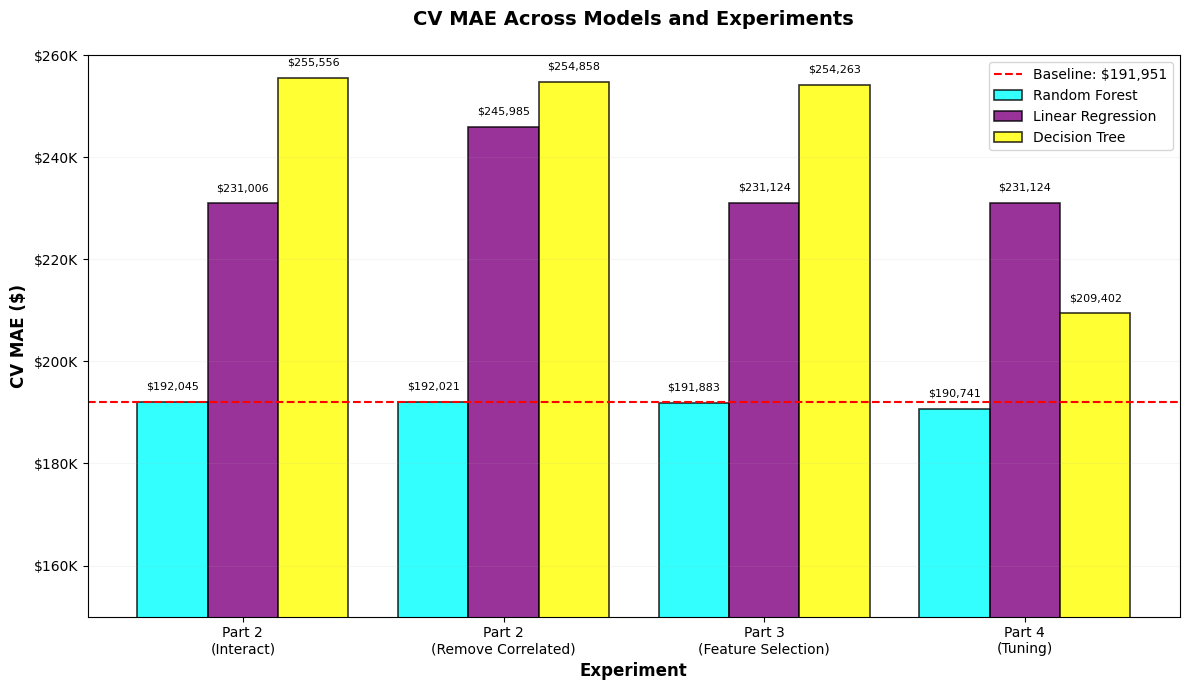

In [44]:
# ============================================
# VISUAL: CV MAE Across Models and Experiments
# ============================================

# Data
parts_labels = ['Part 2\n(Interact)', 'Part 2\n(Remove Correlated)', 'Part 3\n(Feature Selection)', 'Part 4\n(Tuning)']

# CV MAE values
data = {
    'Random Forest': [192045.47, 192021.02, 191882.83, 190741.31],
    'Linear Regression': [231005.71, 245984.97, 231124.46, 231124.46],
    'Decision Tree': [255555.67, 254858.40, 254262.99, 209402.02]
}

std_data = {
    'Random Forest': [3258.94, 3363.03, 3099.32, 3127.89],
    'Linear Regression': [3463.26, 3551.71, 3463.73, 3463.72],
    'Decision Tree': [4012.51, 4406.78, 3863.58, 3609.70]
}

# Baseline CV MAE (Random Forest - Part 1 - Frequency Encoding)
baseline_cv_mae = 191951.14

# Colors
colors = ['aqua', 'purple', 'yellow']
models = ['Random Forest', 'Linear Regression', 'Decision Tree']

# Bar width and positions
bar_width = 0.27
x = np.arange(len(parts_labels))

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars for each model
for idx, (model, color) in enumerate(zip(models, colors)):
    offset = (idx - 1) * bar_width
    bars = ax.bar(x + offset, data[model], bar_width,
                  label=model, color=color, alpha=0.8,
                  edgecolor='black', linewidth=1.2)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, data[model]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=8)

# Add baseline as a dotted horizontal line
ax.axhline(y=baseline_cv_mae, color='red', linestyle='--', linewidth=1.5, 
           label=f'Baseline: ${baseline_cv_mae:,.0f}')

# Formatting
ax.set_xlabel('Experiment', fontsize=12, fontweight='bold')
ax.set_ylabel('CV MAE ($)', fontsize=12, fontweight='bold')
ax.set_title('CV MAE Across Models and Experiments\n', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(parts_labels)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.1, axis='y')
ax.set_ylim(150000, 260000)

# Format y-axis as dollars
ax.yaxis.set_major_formatter(dollars_fmt)

plt.tight_layout()
plt.show()

### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

- In the original baseline **Random Forest** performed best of all models. But with hyperparameter tuning  it **improved slightly**

    | Model | Baseline Mean CV MAE | Hyperparameter-tuned Mean CV MAE | Difference | Interpretation |
    | :--- | :--- | :--- | :--- | :--- |
    | Linear/Ridge Regression | \$245,910.67 | \$231,124.46 | -\$14,786.21 | improved |
    | Random Forest | \$191,951.14 | \$190,583.49 | -\$1,367.65 | improved |
    | Decision Tree | \$254,293.24 | \$209,402.02 | -\$44,891.22 | significantly better |


#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

* From our _**Milestone 1**_ analysis, here were our feature engineering ideas:
  1. Log Transform of Target
  2. Remove Highly Correlated Features
  3. Interaction Features

- Summary of PART 5: Final Model and Workflow Assessment - All Models Across All Parts

  | PART | MODEL | CV MAE | STD |
  | :--- | :---: | ---: | ---: |
  | **-- Baseline --** ||||
  | Part 1 | Linear Regression | $245,910.67 | $3,260.89 |
  | Part 1 | Random Forest     | $191,951.14 | $3,146.39 |
  | Part 1 | Decision Tree     | $254,293.24 | $3,111.16 |
  | **-- Interaction Features --** ||||
  | Part 2 | Linear Regression | $231,005.71 | $3,463.26 |
  | Part 2 | Random Forest     | $192,045.47 | $3,258.94 |
  | Part 2 | Decision Tree     | $255,555.67 | $4,012.51 |
  | **-- Remove Highly Correlated Features --** ||||
  | Part 2 | Linear Regression | $245,984.97 | $3,551.71 |
  | Part 2 | Random Forest     | $192,021.02 | $3,363.03 |
  | Part 2 | Decision Tree     | $254,858.40 | $4,406.78 |
  | **-- Log Transform of Target --** ||||
  | Part 2 | Linear Regression | $331,509.74 | $268,439.58 |
  | Part 2 | Random Forest     | $196,721.21 | $3,555.98 |
  | Part 2 | Decision Tree     | $256,210.83 | $4,180.29 |
  | **-- Feature Selection --** ||||
  | Part 3 | Linear Regression | $231,124.46 | $3,463.73 |
  | Part 3 | Random Forest     | $191,882.83 | $3,099.32 |
  | Part 3 | Decision Tree     | $254,262.99 | $3,863.58 |
  | **-- Hyperparameter Tuning --** ||||
  | Part 4 | Ridge Regression | $231,124.46 | $3,463.72 |
  | Part 4 | Random Forest    | $190,741.31 | $3,127.89 |
  | Part 4 | Decision Tree    | $209,402.02 | $3,609.70 |


* **BEST OVERALL MODEL:**
  * **Random Forest Regressor**
  * Achieved in:       **Part 4 - Hyperparameter Tuning**
  * CV MAE     :       **\$190,741.31**
  * Std CV MAE :       **\$3,127.89**


* **Conclusion. Decisions for Part 5:**
  * Decisions for Part 5:
  * Model:            Random Forest (Tuned)
  * Features:         Original set (28 features)
  * Tuning Method:    Hyperparameter Tuning (Part 4)
  * Best Parameters:  n_estimators=150, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features=0.5

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

- After completing Parts 1–4 we found that **tuned Random Forest** performed the best with **CV MAE** of **\$190,741.31** and **Test MAE** of **\$188,135.66**. Feature selection and feature engineering did not improve performance, but hyperparameter tuning provided a slight improvement.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

- Through this end-to-end workflow, we learned that not every hypothesis leads to improvement. Our idea to remove highly correlated features did not improve model performance, and better results were obtained using the original full feature set.

- One of the biggest practical discoveries was how dramatically the choice of encoding impacts the modeling process. **One-Hot Encoding** exploded the feature space to over 2,900 columns, making the notebook difficult to run on limited free-tier environments like Google Colab and GitHub Codespaces. In contrast, switching to **Frequency Encoding** reduced the feature set to just 28 columns, **cut runtime from over 5 hours to under 1 hour, and preserved most of the predictive performance.**

- If we had more time, we would explore other encoding strategies or feature engineering approaches to further reduce memory and computational requirements while maintaining model accuracy. This experience also highlighted the importance of balancing model complexity with practical considerations like runtime and resource constraints.